In [1]:
# ============================================
# SWIGGY INSTAMART ANALYTICS PROJECT
# 01 - DATA PREPARATION
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# Reproducibility
np.random.seed(42)

# Plot settings
sns.set_style("whitegrid")

print("Libraries loaded successfully!")

Matplotlib is building the font cache; this may take a moment.


Libraries loaded successfully!


In [2]:
# Project paths

PROJECT_ROOT = Path("..")

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "Ecommerce_Delivery_Analytics_New.csv"
)

OUTPUT_FIGURES = (
    PROJECT_ROOT
    / "outputs"
    / "figures"
)

OUTPUT_TABLES = (
    PROJECT_ROOT
    / "outputs"
    / "tables"
)

print("Dataset path:", DATA_PATH)
print("Figures folder:", OUTPUT_FIGURES)
print("Tables folder:", OUTPUT_TABLES)


Dataset path: ..\data\Ecommerce_Delivery_Analytics_New.csv
Figures folder: ..\outputs\figures
Tables folder: ..\outputs\tables


In [3]:
# Create output directories if they don't exist

OUTPUT_FIGURES.mkdir(
    parents=True,
    exist_ok=True
)

OUTPUT_TABLES.mkdir(
    parents=True,
    exist_ok=True
)

print("Output folders ready!")


Output folders ready!


In [4]:
# Check whether the dataset exists

if DATA_PATH.exists():
    print("✅ Dataset found!")
    print(DATA_PATH)
else:
    print("❌ Dataset NOT found!")
    print("Expected location:")
    print(DATA_PATH)

✅ Dataset found!
..\data\Ecommerce_Delivery_Analytics_New.csv


In [5]:
# Load the dataset

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 100000
Columns: 11


In [6]:
df.head()

,Order ID,Customer ID,Platform,Order Date & Time,Delivery Time (Minutes),Product Category,Order Value (INR),Customer Feedback,Service Rating,Delivery Delay,Refund Requested
0,ORD000001,CUST2824,JioMart,19:29.5,30,Fruits & Vegetables,382,"Fast delivery, great service!",5,No,No
1,ORD000002,CUST1409,Blinkit,54:29.5,16,Dairy,279,Quick and reliable!,5,No,No
2,ORD000003,CUST5506,JioMart,21:29.5,25,Beverages,599,Items missing from order.,2,No,Yes
3,ORD000004,CUST5012,JioMart,19:29.5,42,Beverages,946,Items missing from order.,2,Yes,Yes
4,ORD000005,CUST4657,Blinkit,49:29.5,30,Beverages,334,"Fast delivery, great service!",5,No,No


In [7]:
df.shape

(100000, 11)

In [8]:
df.columns.tolist()

['Order ID',
 'Customer ID',
 'Platform',
 'Order Date & Time',
 'Delivery Time (Minutes)',
 'Product Category',
 'Order Value (INR)',
 'Customer Feedback',
 'Service Rating',
 'Delivery Delay',
 'Refund Requested']

In [9]:
df["Platform"].value_counts(dropna=False)

Platform
Swiggy Instamart    33449
Blinkit             33424
JioMart             33127
Name: count, dtype: int64

In [10]:
# Filter for Swiggy Instamart

instamart = df[
    df["Platform"]
    .astype(str)
    .str.strip()
    .str.lower()
    == "swiggy instamart"
].copy()

print("Original dataset shape:", df.shape)
print("Instamart dataset shape:", instamart.shape)


Original dataset shape: (100000, 11)
Instamart dataset shape: (33449, 11)


In [11]:
instamart["Platform"].value_counts()

Platform
Swiggy Instamart    33449
Name: count, dtype: int64

In [12]:
instamart["Order Date & Time"] = pd.to_datetime(
    instamart["Order Date & Time"],
    errors="coerce"
)

print(
    instamart["Order Date & Time"].dtype
)

datetime64[us]


C:\Users\dell\AppData\Local\Temp\ipykernel_30520\2995206048.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  instamart["Order Date & Time"] = pd.to_datetime(


In [13]:
instamart.isnull().sum()

Order ID                       0
Customer ID                    0
Platform                       0
Order Date & Time          20129
Delivery Time (Minutes)        0
Product Category               0
Order Value (INR)              0
Customer Feedback              0
Service Rating                 0
Delivery Delay                 0
Refund Requested               0
dtype: int64

In [14]:
print(instamart.shape)
print(instamart.isnull().sum())

(33449, 11)
Order ID                       0
Customer ID                    0
Platform                       0
Order Date & Time          20129
Delivery Time (Minutes)        0
Product Category               0
Order Value (INR)              0
Customer Feedback              0
Service Rating                 0
Delivery Delay                 0
Refund Requested               0
dtype: int64


In [15]:
print("Duplicate rows:", instamart.duplicated().sum())

print(
    "Duplicate Order IDs:",
    instamart["Order ID"].duplicated().sum()
)

Duplicate rows: 0
Duplicate Order IDs: 0


In [16]:
print("Earliest order date:")
print(instamart["Order Date & Time"].min())

print("\nLatest order date:")
print(instamart["Order Date & Time"].max())

Earliest order date:
2026-08-24 00:29:30

Latest order date:
2026-08-24 23:29:30


In [17]:
date_completeness = (
    instamart["Order Date & Time"]
    .notna()
    .value_counts()
)

print(date_completeness)

Order Date & Time
False    20129
True     13320
Name: count, dtype: int64


In [18]:
# Create dataset containing only rows with valid order dates

instamart_temporal = instamart[
    instamart["Order Date & Time"].notna()
].copy()

print("All Instamart rows:", len(instamart))
print("Rows with valid dates:", len(instamart_temporal))
print("Rows excluded due to missing dates:",
      len(instamart) - len(instamart_temporal))

All Instamart rows: 33449
Rows with valid dates: 13320
Rows excluded due to missing dates: 20129


In [19]:
print(
    "Earliest order:",
    instamart_temporal["Order Date & Time"].min()
)

print(
    "Latest order:",
    instamart_temporal["Order Date & Time"].max()
)


Earliest order: 2026-08-24 00:29:30
Latest order: 2026-08-24 23:29:30


In [20]:
print(
    "Unique customers:",
    instamart_temporal["Customer ID"].nunique()
)

print(
    "Unique orders:",
    instamart_temporal["Order ID"].nunique()
)

Unique customers: 6983
Unique orders: 13320


In [ ]:
# Create dataset containing only rows with valid order dates

instamart_temporal = instamart[
    instamart["Order Date & Time"].notna()
].copy()

print("All Instamart rows:", len(instamart))
print("Rows with valid dates:", len(instamart_temporal))
print("Rows excluded due to missing dates:",
      len(instamart) - len(instamart_temporal))

All Instamart rows: 33449
Rows with valid dates: 13320
Rows excluded due to missing dates: 20129


In [21]:
# ==========================================
# CUSTOMER ORDER BEHAVIOR
# ==========================================

orders_per_customer = (
    instamart_temporal
    .groupby("Customer ID")["Order ID"]
    .nunique()
)

print("Orders per customer:")
print(orders_per_customer.describe())

Orders per customer:
count    6983.000000
mean        1.907490
std         1.019309
min         1.000000
25%         1.000000
50%         2.000000
75%         2.000000
max         8.000000
Name: Order ID, dtype: float64


In [22]:
# Customer repeat-order distribution

repeat_customers = (
    orders_per_customer > 1
).sum()

one_time_customers = (
    orders_per_customer == 1
).sum()

total_customers = len(orders_per_customer)

print(f"One-time customers: {one_time_customers:,}")
print(f"Repeat customers: {repeat_customers:,}")

print(
    f"Repeat customer rate: "
    f"{repeat_customers / total_customers:.2%}"
)

One-time customers: 3,048
Repeat customers: 3,935
Repeat customer rate: 56.35%


In [23]:
customer_features = (
    instamart_temporal
    .groupby("Customer ID")
    .agg(
        Order_Frequency=(
            "Order ID",
            "nunique"
        ),

        Avg_Order_Value=(
            "Order Value (INR)",
            "mean"
        ),

        Avg_Delivery_Time=(
            "Delivery Time (Minutes)",
            "mean"
        ),

        Delay_Ratio=(
            "Delivery Delay",
            lambda x: (x == "Yes").mean()
        ),

        Avg_Rating=(
            "Service Rating",
            "mean"
        ),

        Refund_Rate=(
            "Refund Requested",
            lambda x: (x == "Yes").mean()
        )
    )
    .reset_index()
)

customer_features.head()

,Customer ID,Order_Frequency,Avg_Order_Value,Avg_Delivery_Time,Delay_Ratio,Avg_Rating,Refund_Rate
0,CUST1000,2,466.50,26.50,0.0,3.50,0.50
1,CUST1001,4,420.25,26.25,0.0,2.75,0.75
2,CUST1002,1,611.00,32.00,0.0,4.00,0.00
3,CUST1003,1,128.00,31.00,0.0,1.00,1.00
4,CUST1005,1,306.00,29.00,0.0,2.00,1.00


In [26]:
customer_features.describe()


,Order_Frequency,Avg_Order_Value,Avg_Delivery_Time,Delay_Ratio,Avg_Rating,Refund_Rate
count,6983.000000,6983.000000,6983.000000,6983.000000,6983.000000,6983.000000
mean,1.907490,592.705335,29.434921,0.136361,3.243436,0.456855
std,1.019309,344.741303,8.148094,0.279764,1.292264,0.406299
min,1.000000,51.000000,5.000000,0.000000,1.000000,0.000000
25%,1.000000,346.000000,24.000000,0.000000,2.000000,0.000000
50%,2.000000,526.000000,29.333333,0.000000,3.250000,0.500000
75%,2.000000,764.000000,34.500000,0.000000,4.500000,1.000000
max,8.000000,1991.000000,58.000000,1.000000,5.000000,1.000000


In [27]:
customer_features.info()

<class 'pandas.DataFrame'>
RangeIndex: 6983 entries, 0 to 6982
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Customer ID        6983 non-null   str    
 1   Order_Frequency    6983 non-null   int64  
 2   Avg_Order_Value    6983 non-null   float64
 3   Avg_Delivery_Time  6983 non-null   float64
 4   Delay_Ratio        6983 non-null   float64
 5   Avg_Rating         6983 non-null   float64
 6   Refund_Rate        6983 non-null   float64
dtypes: float64(5), int64(1), str(1)
memory usage: 382.0 KB


In [28]:
# ==========================================
# CUSTOMER EXPERIENCE ANALYSIS
# ==========================================

delay_analysis = (
    instamart_temporal
    .groupby("Delivery Delay")
    .agg(
        Orders=("Order ID", "nunique"),
        Avg_Rating=("Service Rating", "mean"),
        Avg_Delivery_Time=("Delivery Time (Minutes)", "mean"),
        Avg_Order_Value=("Order Value (INR)", "mean"),
        Refund_Rate=(
            "Refund Requested",
            lambda x: (x == "Yes").mean()
        )
    )
    .reset_index()
)

delay_analysis

,Delivery Delay,Orders,Avg_Rating,Avg_Delivery_Time,Avg_Order_Value,Refund_Rate
0,No,11498,3.238563,26.937641,594.475735,0.458341
1,Yes,1822,3.206367,45.557629,589.008782,0.463227


In [29]:
refund_analysis = (
    instamart_temporal
    .groupby("Refund Requested")
    .agg(
        Orders=("Order ID", "nunique"),
        Avg_Rating=("Service Rating", "mean"),
        Avg_Delivery_Time=(
            "Delivery Time (Minutes)",
            "mean"
        ),
        Avg_Order_Value=("Order Value (INR)", "mean")
    )
    .reset_index()
)

refund_analysis

,Refund Requested,Orders,Avg_Rating,Avg_Delivery_Time,Avg_Order_Value
0,No,7206,4.569387,29.482098,595.055648
1,Yes,6114,1.660451,29.487570,592.163068


In [31]:
refund_analysis = (
    instamart_temporal
    .groupby("Refund Requested")
    .agg(
        Orders=("Order ID", "nunique"),
        Avg_Rating=("Service Rating", "mean"),
        Avg_Delivery_Time=(
            "Delivery Time (Minutes)",
            "mean"
        ),
        Avg_Order_Value=("Order Value (INR)", "mean")
    )
    .reset_index()
)

refund_analysis

,Refund Requested,Orders,Avg_Rating,Avg_Delivery_Time,Avg_Order_Value
0,No,7206,4.569387,29.482098,595.055648
1,Yes,6114,1.660451,29.487570,592.163068


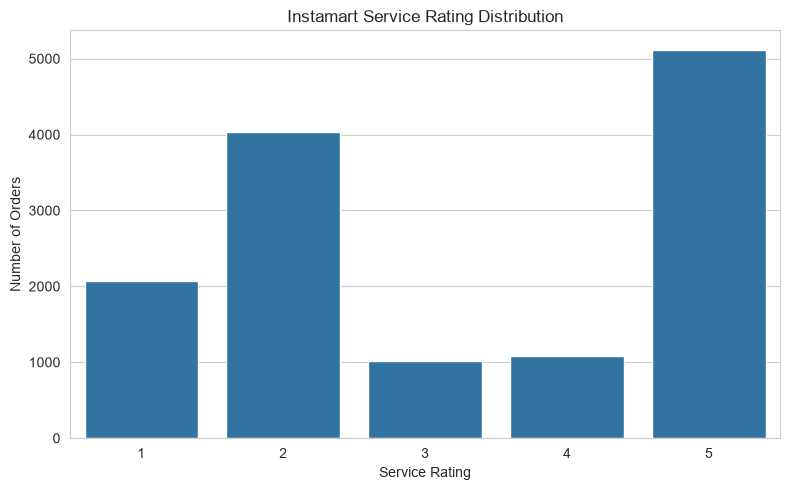

In [32]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=instamart_temporal,
    x="Service Rating"
)

plt.title("Instamart Service Rating Distribution")
plt.xlabel("Service Rating")
plt.ylabel("Number of Orders")

plt.tight_layout()

plt.savefig(
    OUTPUT_FIGURES / "rating_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [33]:
def experience_segment(row):

    if (
        row["Avg_Rating"] < 3
        or row["Delay_Ratio"] > 0.30
        or row["Refund_Rate"] > 0.50
    ):
        return "High Risk Experience"

    elif (
        row["Avg_Rating"] < 4
        or row["Delay_Ratio"] > 0.15
        or row["Refund_Rate"] > 0.25
    ):
        return "Medium Risk Experience"

    else:
        return "Healthy Experience"


customer_features["Experience_Segment"] = (
    customer_features
    .apply(experience_segment, axis=1)
)

customer_features["Experience_Segment"].value_counts()

Experience_Segment
High Risk Experience      3662
Healthy Experience        1881
Medium Risk Experience    1440
Name: count, dtype: int64

In [34]:
segment_analysis = (
    customer_features
    .groupby("Experience_Segment")
    .agg(
        Customers=("Customer ID", "nunique"),
        Avg_Order_Frequency=(
            "Order_Frequency",
            "mean"
        ),
        Avg_Order_Value=(
            "Avg_Order_Value",
            "mean"
        ),
        Avg_Delivery_Time=(
            "Avg_Delivery_Time",
            "mean"
        ),
        Avg_Rating=(
            "Avg_Rating",
            "mean"
        ),
        Avg_Delay_Ratio=(
            "Delay_Ratio",
            "mean"
        ),
        Avg_Refund_Rate=(
            "Refund_Rate",
            "mean"
        )
    )
    .sort_values("Avg_Rating")
    .reset_index()
)

segment_analysis

,Experience_Segment,Customers,Avg_Order_Frequency,Avg_Order_Value,Avg_Delivery_Time,Avg_Rating,Avg_Delay_Ratio,Avg_Refund_Rate
0,High Risk Experience,3662,1.919170,593.921855,31.661672,2.413051,0.252327,0.724079
1,Medium Risk Experience,1440,2.468056,585.516310,27.252543,3.369506,0.019575,0.368282
2,Healthy Experience,1881,1.455609,595.840528,26.770521,4.763548,0.000000,0.004421


In [35]:
segment_analysis.to_csv(
    OUTPUT_TABLES / "customer_experience_segments.csv",
    index=False
)

customer_features.to_csv(
    OUTPUT_TABLES / "customer_features.csv",
    index=False
)

print("Customer analytics outputs saved successfully.")

Customer analytics outputs saved successfully.


In [36]:
# ==========================================
# SAVE CLEAN INSTAMART DATASET
# ==========================================

cleaned_path = (
    PROJECT_ROOT
    / "data"
    / "instamart_cleaned.csv"
)

instamart.to_csv(
    cleaned_path,
    index=False
)

print("Clean Instamart dataset saved:")
print(cleaned_path)
print("Rows:", len(instamart))

Clean Instamart dataset saved:
..\data\instamart_cleaned.csv
Rows: 33449


In [37]:
# ==========================================
# SAVE TEMPORAL INSTAMART DATASET
# ==========================================

temporal_path = (
    PROJECT_ROOT
    / "data"
    / "instamart_temporal.csv"
)

instamart_temporal.to_csv(
    temporal_path,
    index=False
)

print("Temporal dataset saved:")
print(temporal_path)
print("Rows:", len(instamart_temporal))

Temporal dataset saved:
..\data\instamart_temporal.csv
Rows: 13320
